
WYMAGANIA  
1. Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1) + oraz duplikatów 
2. Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
3. Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
4. Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
5. Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
6. Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków


In [1]:
#poukładanie cech w kolumnach
#Survived	
#Pclass	    encoding ??
#Name	      możliwe że nie ma znaczenia (zobaczyc czy nie ma 2 tych samych osoób)
#Sex	      encoding ??
#Age	    
#SibSp	    możliwe że nie ma znaczenia
#Parch	    możliwe że nie ma znaczenia
#Ticket	    
#Fare	    
#Cabin      encoding ??

In [2]:
import numpy as np 
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD

base_path = Path(".")

tytanik = pd.read_csv(base_path / 'titanic.csv')

print(tytanik.head()) #podgląd danych


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
#1.
def get_percentage_missing(df, axis):
  """
    Zwraca procent brakujących wartości (NaN) w wierszach lub kolumnach DataFrame.

    df : pandas.DataFrame
        Tabela danych, dla której liczone są braki.

    axis : int
        Oś, względem której obliczane są braki:
        - 0 : procent braków w każdej kolumnie
        - 1 : procent braków w każdym wierszu
  """
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

braki_w_kolumnach = get_percentage_missing(tytanik, axis=0)
print(braki_w_kolumnach)
#Age         19.87 - średnia ??
#Fare        11.00 - związek miedzy 'Ticket' ??
#Cabin       77.10 - ???
#Embarked     0.22 - uzupełnić losowo (bo jest bardzo mało)

missing_rows_ti = get_percentage_missing(tytanik, axis=1)

missing_all_column_values = missing_rows_ti[missing_rows_ti == 100].index
#print(missing_all_column_values) #puste wiersze (najlepiej je usunąć - nie ma takich)\

#print(tytanik.duplicated().sum()) #sprawdze czy są duplikaty wierszy - nie ma ich

#Age
#tytanik['Age'] = tytanik['Age'].fillna(tytanik['Age'].median()) uzupełnie medią

tytanik['Age'] = tytanik['Age'].fillna(tytanik.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
# uzupełniamu medianę, ale z korelacją na 'Sex' a 'Age' i 'Pclass' 

#Fare
tytanik['Fare'] = tytanik['Fare'].fillna(tytanik.groupby('Ticket')['Fare'].transform('median')) 
#uzupełnie 'Fare' o mednianą tych samych biletów (Ticket) 

tytanik['Fare'] = tytanik['Fare'].fillna(tytanik.groupby('Pclass')['Fare'].transform('median')) 
#obliczenie reszty brakującej medianą, ale mając na uwadze 'Pclass'

duplikaty_biletow = tytanik[tytanik.duplicated(subset=['Ticket'], keep=False)]
#print(duplikaty_biletow.sort_values(by='Ticket'))

#zmiejszyliśmy braki w kolumnie 'Fare' 3,82 punktów %

#Cabin
tytanik['Cabin'] = tytanik['Cabin'].notna().astype(int)

tytanik = tytanik.rename(columns={'Cabin': 'Has_Cabin'})

#Embarked
tytanik['Embarked'] = tytanik['Embarked'].fillna(tytanik['Embarked'].mode()[0]) 
#uzupełnienie najczęstszą wartością (modą), zamiast losowo

Age         19.87
Fare        11.00
Cabin       77.10
Embarked     0.22
dtype: float64


In [4]:
#2 + #3
"""usuwam kolumne Name i PassengerId"""
tytanik = tytanik.drop(columns=['Name', 'PassengerId'])
#print(tytanik.head())
""" teraz jest szansa że wiersze bedą sie powtarzać, ale to nie przeszkadza"""
""" możliwe że w tych danych jest korelacje miedzy nazwiskiem a przezywalności, ale szczerze to troche nie mam zamiaru tego sprawdzać""" 

"""Encoding kolumny 'Sex' """
tytanik.insert(2, 'Male', (tytanik['Sex'] == 'male').astype(int))

tytanik = tytanik.drop(columns=['Sex']) # usuwanie starej kolumny

"""Encoding kolumny 'Embarked' """
tytanik = pd.get_dummies(tytanik, columns=['Embarked'], dtype=int)

"""Encoding kolumny 'Embarked' """
tytanik = tytanik.drop(columns=['Ticket']) 
#troche nie wiem co z nią zrobić, bo mazna ni by pobrupować z odciąciem liter
#troche bez sensu wcześniej są uzupełniłem ale trudno 
print(tytanik.head())

   Survived  Pclass  Male   Age  SibSp  Parch     Fare  Has_Cabin  Embarked_C  \
0         0       3     1  22.0      1      0   7.2500          0           0   
1         1       1     0  38.0      1      0  71.2833          1           1   
2         1       3     0  26.0      0      0   7.9250          0           0   
3         1       1     0  35.0      1      0  53.1000          1           0   
4         0       3     1  35.0      0      0   8.0500          0           0   

   Embarked_Q  Embarked_S  
0           0           1  
1           0           0  
2           0           1  
3           0           1  
4           0           1  


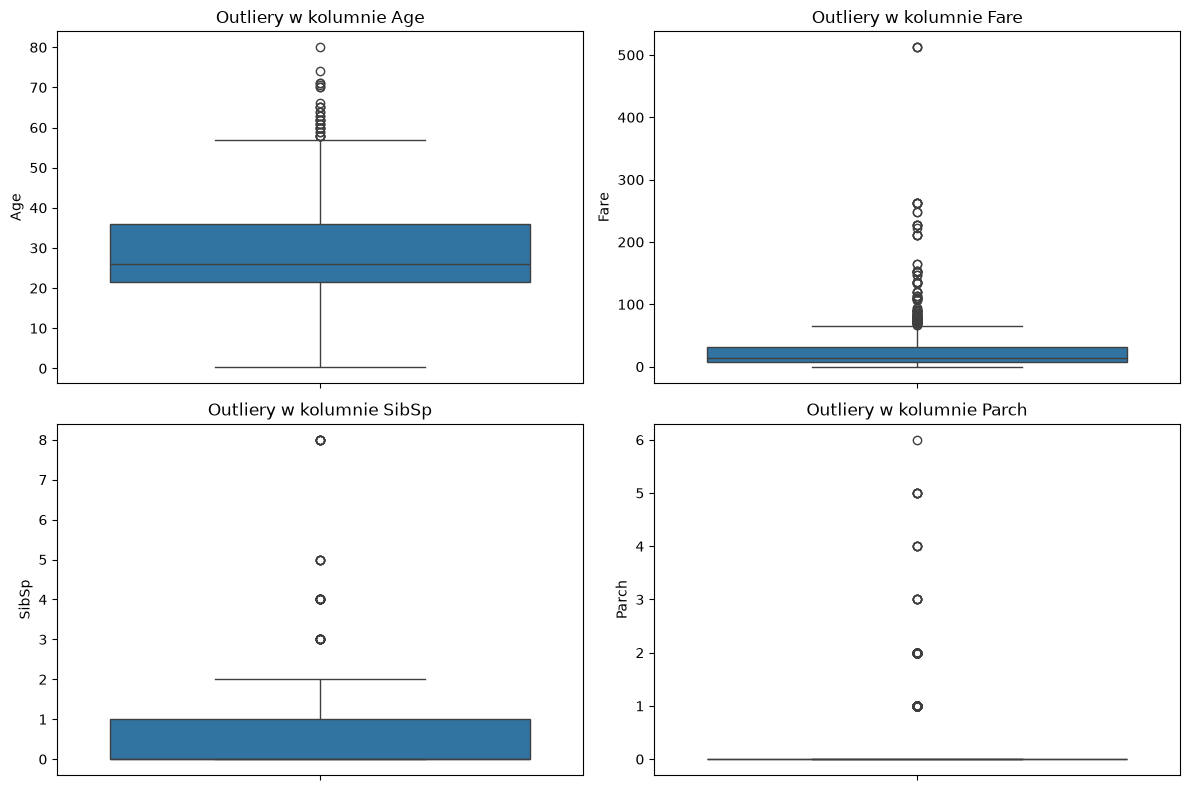

In [5]:
#4
kolumny_numeryczne = ['Age', 'Fare', 'SibSp', 'Parch']
plt.figure(figsize=(12, 8))

for i, kolumna in enumerate(kolumny_numeryczne, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=tytanik[kolumna])
    plt.title(f'Outliery w kolumnie {kolumna}')

plt.tight_layout() 
plt.show()

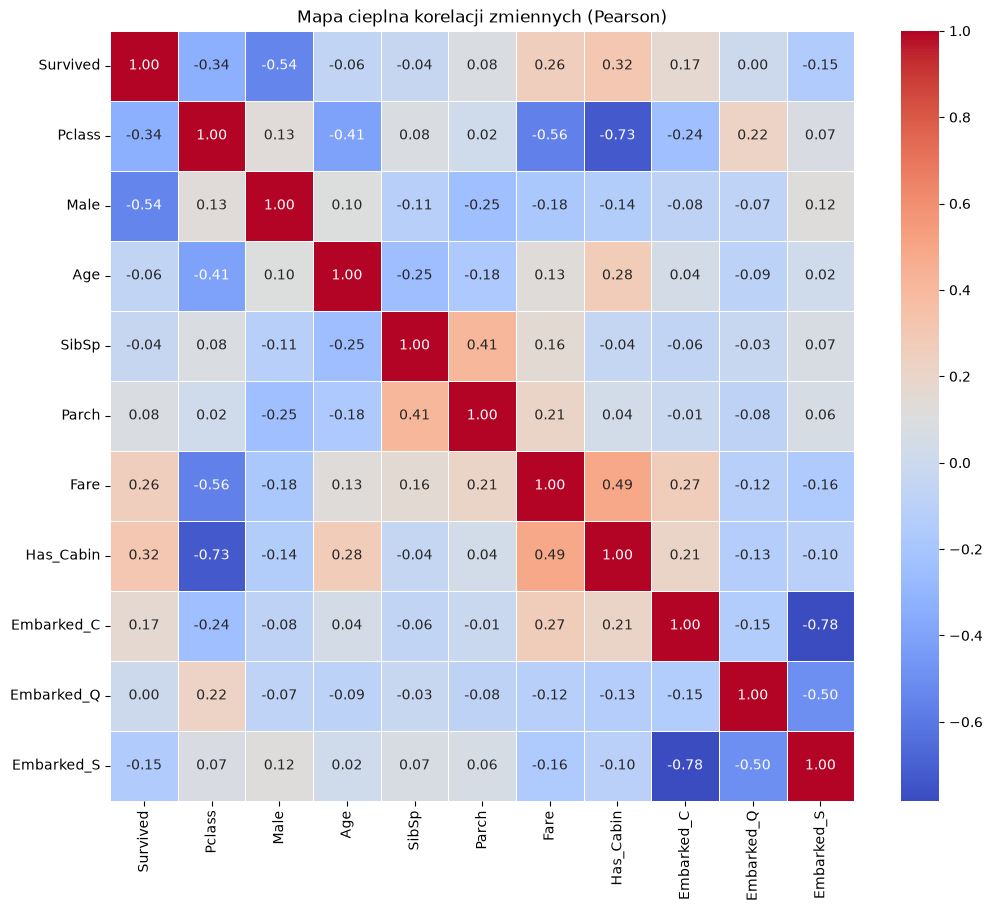

In [6]:
#5
kolumny_numeryczne = tytanik.select_dtypes(include=['number'])

macierz_korelacji = kolumny_numeryczne.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(macierz_korelacji, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Mapa cieplna korelacji zmiennych (Pearson)')
plt.show()

In [7]:
#6 DODATKOWE

#scaler = StandardScaler()
#tytanik_scaled = scaler.fit_transform(tytanik)

# PCA 
#pca = PCA(n_components=2)
#wynik_pca = pca.fit_transform(tytanik_scaled)

#print("Wymiary po PCA:", wynik_pca.shape)
#print(wynik_pca) 

# SVD 
#svd = TruncatedSVD(n_components=2)
#wynik_svd = svd.fit_transform(tytanik_scaled)

#print("Wymiary po SVD:", wynik_svd.shape)

# i teraz naiwym bayes'em można estymować czy nowy pasazer przezyje czy nie

In [8]:
from pathlib import Path

katalog_docelowy = Path("../02_podstawy_aiml")

katalog_docelowy.mkdir(parents=True, exist_ok=True)

tytanik.to_csv(katalog_docelowy / 'titanic_ready.csv', index=False)
#tworzenie pliku z gotowymi danymi
